# Imports

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import seaborn as sns
import joblib
from IPython.core.display import HTML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from datetime import datetime
from sklearn.feature_extraction.text import CountVectorizer
from pandas import DataFrame
from collections import OrderedDict 
from colorama import Fore, Back, Style
y_ = Fore.YELLOW
r_ = Fore.RED
g_ = Fore.GREEN
b_ = Fore.BLUE
m_ = Fore.MAGENTA
sr_ = Style.RESET_ALL

# Reading the csv file

In [9]:
df = pd.read_csv(r'news_articles.csv', encoding="latin", index_col=0)
df = df.dropna()
df.count()

published                  2045
title                      2045
text                       2045
language                   2045
site_url                   2045
main_img_url               2045
type                       2045
label                      2045
title_without_stopwords    2045
text_without_stopwords     2045
hasImage                   2045
dtype: int64

In [10]:
real = df["label"].loc[df["label"] == "Real"].count()
fake = df["label"].loc[df["label"] == "Fake"].count()

print("No. of real new :", real)
print("No. of fake new :", fake)

No. of real new : 754
No. of fake new : 1291


In [11]:
df.head(5)

,published,title,text,language,site_url,main_img_url,type,label,title_without_stopwords,text_without_stopwords,hasImage
author,,,,,,,,,,,
Barracuda Brigade,2016-10-26T21:41:00.000+03:00,muslims busted they stole millions in govt ben...,print they should pay all the back all the mon...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,muslims busted stole millions govt benefits,print pay back money plus interest entire fami...,1.0
reasoning with facts,2016-10-29T08:47:11.259+03:00,re why did attorney general loretta lynch plea...,why did attorney general loretta lynch plead t...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,attorney general loretta lynch plead fifth,attorney general loretta lynch plead fifth bar...,1.0
Barracuda Brigade,2016-10-31T01:41:49.479+02:00,breaking weiner cooperating with fbi on hillar...,red state \nfox news sunday reported this mor...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,breaking weiner cooperating fbi hillary email ...,red state fox news sunday reported morning ant...,1.0
Fed Up,2016-11-01T05:22:00.000+02:00,pin drop speech by father of daughter kidnappe...,email kayla mueller was a prisoner and torture...,english,100percentfedup.com,http://100percentfedup.com/wp-content/uploads/...,bias,Real,pin drop speech father daughter kidnapped kill...,email kayla mueller prisoner tortured isis cha...,1.0
Fed Up,2016-11-01T21:56:00.000+02:00,fantastic trumps point plan to reform healthc...,email healthcare reform to make america great ...,english,100percentfedup.com,http://100percentfedup.com/wp-content/uploads/...,bias,Real,fantastic trumps point plan reform healthcare ...,email healthcare reform make america great sin...,1.0


In [12]:
df['type'].unique()

array(['bias', 'conspiracy', 'fake', 'bs', 'satire', 'hate', 'junksci',
       'state'], dtype=object)

# Distrubution of types of articles

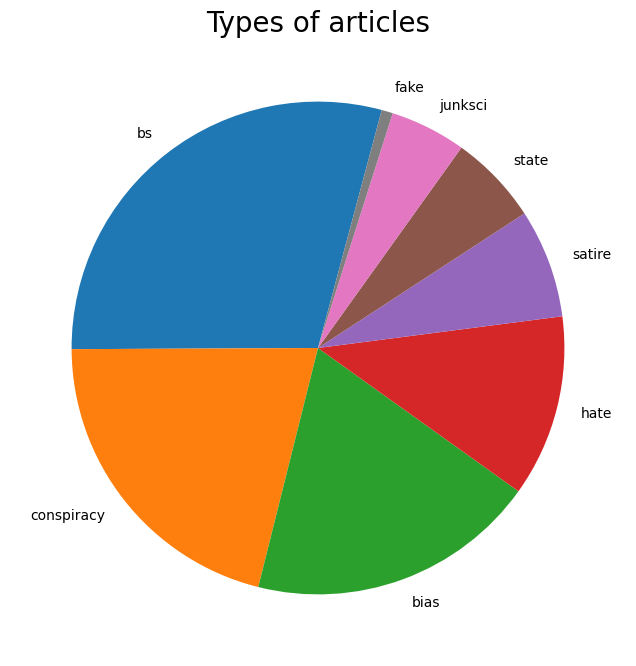

In [13]:
df['type'].value_counts().plot.pie(figsize = (8,8), startangle = 75)
plt.title('Types of articles', fontsize = 20)
plt.axis('off')
plt.show()

# Unigrams and bigrams 

In [14]:
def get_top_n_words(corpus, n=None):
    vec = CountVectorizer().fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in     vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

def get_top_n_bigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]


def get_top_n_trigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

<Axes: title={'center': 'Top 20 bigrams used in articles'}, xlabel='words', ylabel='Count'>

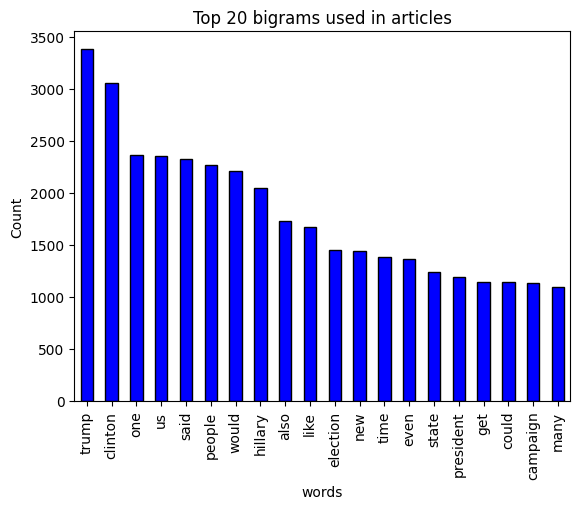

In [15]:
common_words = get_top_n_words(df['text_without_stopwords'], 20)
df3 = pd.DataFrame(common_words, columns=['words', 'count'])

df3.groupby('words').sum()['count'].sort_values(ascending=False).plot(
    kind='bar',
    ylabel='Count',  
    title='Top 20 bigrams used in articles',
    color='blue',
    edgecolor='black' 
)


<Axes: title={'center': 'Top 20 bigrams used in articles'}, xlabel='words', ylabel='Count'>

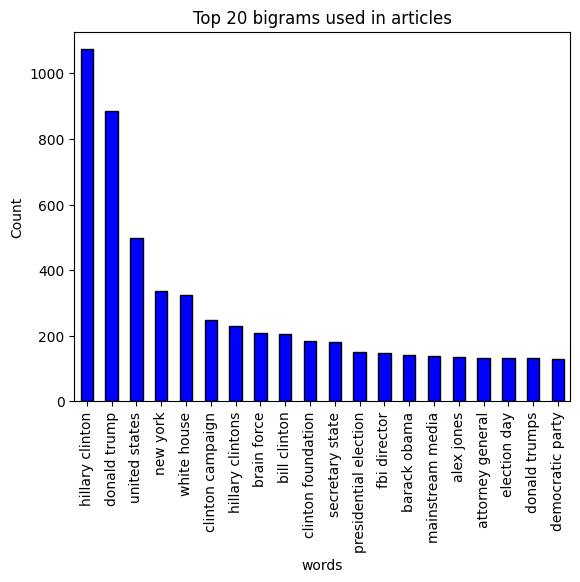

In [16]:
common_words = get_top_n_bigram(df['text_without_stopwords'], 20)
df3 = pd.DataFrame(common_words, columns=['words', 'count'])

df3.groupby('words').sum()['count'].sort_values(ascending=False).plot(
    kind='bar',
    ylabel='Count',  
    title='Top 20 bigrams used in articles',
    color='blue',
    edgecolor='black' 
)


# WordCloud of articles

# Articles including images vs Label

In [17]:
fig = px.bar(df, x='hasImage', y='label',title='Articles including images vs Label')
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
def convert(path):
    return '<img src="'+ path + '" width="80">'

In [ ]:
df_sources = df[['site_url','label','main_img_url']]
df_r = df_sources.loc[df['label']== 'Real'].iloc[6:10,:]
df_f = df_sources.loc[df['label']== 'Fake'].head(6)

In [ ]:
HTML(df_r.to_html(escape=False,formatters=dict(main_img_url=convert)))

,site_url,label,main_img_url
author,,,
Fed Up,100percentfedup.com,Real,
Fed Up,100percentfedup.com,Real,
Fed Up,100percentfedup.com,Real,
Fed Up,100percentfedup.com,Real,


In [ ]:
HTML(df_f.to_html(escape=False,formatters=dict(main_img_url=convert)))

,site_url,label,main_img_url
author,,,
No Author,21stcenturywire.com,Fake,
No Author,21stcenturywire.com,Fake,
Shawn Helton,21stcenturywire.com,Fake,
Mike Rivero,21stcenturywire.com,Fake,
No Author,21stcenturywire.com,Fake,
Shawn Helton,21stcenturywire.com,Fake,


In [ ]:
df['site_url'].unique()

array(['100percentfedup.com', '21stcenturywire.com', 'abcnews.com.co',
       'abeldanger.net', 'abovetopsecret.com', 'activistpost.com',
       'addictinginfo.org', 'adobochronicles.com', 'ahtribune.com',
       'allnewspipeline.com', 'americannews.com',
       'americasfreedomfighters.com', 'amren.com', 'amtvmedia.com',
       'awdnews.com', 'barenakedislam.com', 'clickhole.com',
       'coasttocoastam.com', 'corbettreport.com', 'countercurrents.org',
       'counterpunch.org', 'dailywire.com', 'darkmoon.me',
       'davidduke.com', 'davidstockmanscontracorner.com',
       'davidwolfe.com', 'dcclothesline.com', 'defenddemocracy.press',
       'dennismichaellynch.com', 'departed.co', 'der-postillon.com',
       'fromthetrenchesworldreport.com', 'frontpagemag.com',
       'galacticconnection.com', 'globalresearch.ca', 'infowars.com',
       'intrepidreport.com', 'legorafi.fr', 'madworldnews.com',
       'naturalnews.com', 'newstarget.com', 'politicususa.com',
       'presstv.com', 'pre

In [ ]:
type_label = {'Real': 0, 'Fake': 1}
df_sources.label = [type_label[item] for item in df_sources.label] 

C:\Users\KIIT\AppData\Local\Temp\ipykernel_16592\583969651.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
val_real=[]
val_fake=[]

for i,row in df_sources.iterrows():
    val = row['site_url']
    if row['label'] == 0:
        val_real.append(val)
    elif row['label']== 1:
        val_fake.append(val)

> # Websites publishing real news

In [ ]:
uniqueValues_real = list(OrderedDict.fromkeys(val_real)) 

print(f"{y_}Websites publishing real news:{g_}{uniqueValues_real}\n") 

Websites publishing real news:['100percentfedup.com', 'addictinginfo.org', 'dailywire.com', 'davidduke.com', 'fromthetrenchesworldreport.com', 'frontpagemag.com', 'newstarget.com', 'politicususa.com', 'presstv.com', 'presstv.ir', 'prisonplanet.com', 'proudemocrat.com', 'redstatewatcher.com', 'returnofkings.com', 'washingtonsblog.com', 'westernjournalism.com', 'whydontyoutrythis.com', 'wnd.com']



# Websites publishing fake news

In [ ]:
uniqueValues_fake = list(OrderedDict.fromkeys(val_fake)) 
print(f"{y_}Websites publishing fake news:{r_}{uniqueValues_fake}\n")

Websites publishing fake news:['21stcenturywire.com', 'abcnews.com.co', 'abeldanger.net', 'abovetopsecret.com', 'activistpost.com', 'adobochronicles.com', 'ahtribune.com', 'allnewspipeline.com', 'americannews.com', 'americasfreedomfighters.com', 'amren.com', 'amtvmedia.com', 'awdnews.com', 'barenakedislam.com', 'clickhole.com', 'coasttocoastam.com', 'corbettreport.com', 'countercurrents.org', 'counterpunch.org', 'darkmoon.me', 'davidduke.com', 'davidstockmanscontracorner.com', 'davidwolfe.com', 'dcclothesline.com', 'defenddemocracy.press', 'dennismichaellynch.com', 'departed.co', 'der-postillon.com', 'fromthetrenchesworldreport.com', 'frontpagemag.com', 'galacticconnection.com', 'globalresearch.ca', 'infowars.com', 'intrepidreport.com', 'legorafi.fr', 'madworldnews.com', 'naturalnews.com', 'newstarget.com', 'presstv.ir', 'prisonplanet.com', 'projectveritas.com', 'returnofkings.com', 'shiftfrequency.com', 'thedailysheeple.com', 'theeconomiccollapseblog.com', 'thefreethoughtproject.com',

# Websites publishing both real and fake news

In [ ]:
real_set = set(uniqueValues_real) 
fake_set = set(uniqueValues_fake) 

print(f"{y_}Websites publishing both real and fake news:{m_}{real_set & fake_set}\n")

Websites publishing both real and fake news:{'prisonplanet.com', 'westernjournalism.com', 'presstv.ir', 'davidduke.com', 'fromthetrenchesworldreport.com', 'frontpagemag.com', 'washingtonsblog.com', 'returnofkings.com', 'newstarget.com'}



In [ ]:
type1 = {'bias': 0, 'conspiracy': 1,'fake': 2,'bs': 3,'satire': 4, 'hate': 5,'junksci': 6, 'state': 7}
df.type = [type1[item] for item in df.type] 

In [ ]:
def plot_bar(df, feat_x, feat_y, normalize=True):
    """ Plot with vertical bars of the requested dataframe and features"""
    
    ct = pd.crosstab(df[feat_x], df[feat_y])
    if normalize == True:
        ct = ct.div(ct.sum(axis=1), axis=0)
    return ct.plot(kind='bar', stacked=True)

# Label vs Type

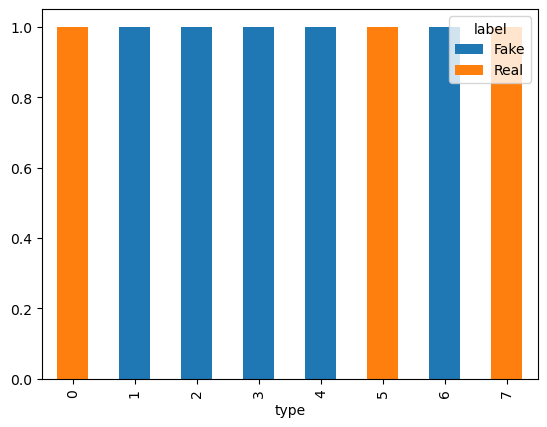

In [ ]:
plot_bar(df,'type' , 'label')
plt.show()

In [ ]:
fig = px.sunburst(df, path=['label', 'type'])
fig.show()

# Websites and types of news published

In [ ]:
df_type = df[['site_url','type']]

val_bias=[]
val_conspiracy=[]
val_fake1=[]
val_bs=[]
val_satire=[]
val_hate=[]
val_junksci=[]
val_state=[]
{'bias': 0, 'conspiracy': 1,'fake': 2,'bs': 3,'satire': 4, 'hate': 5,'junksci': 6, 'state': 7}
for i,row in df_type.iterrows():
    val = row['site_url']
    if row['type'] == 0:
        val_bias.append(val)
    elif row['type']== 1:
        val_conspiracy.append(val)
    elif row['type']== 2:
        val_fake1.append(val)
    elif row['type']== 3:
        val_bs.append(val)
    elif row['type']== 4:
        val_satire.append(val)
    elif row['type']== 5:
        val_hate.append(val)
    elif row['type']== 6:
        val_junksci.append(val)
    elif row['type']== 7:
        val_state.append(val)

In [ ]:
uv_bias = list(OrderedDict.fromkeys(val_bias)) 
uv_conspiracy = list(OrderedDict.fromkeys(val_conspiracy)) 
uv_fake = list(OrderedDict.fromkeys(val_fake1)) 
uv_bs = list(OrderedDict.fromkeys(val_bs)) 
uv_satire = list(OrderedDict.fromkeys(val_satire)) 
uv_hate = list(OrderedDict.fromkeys(val_hate)) 
uv_junksci = list(OrderedDict.fromkeys(val_junksci)) 
uv_state = list(OrderedDict.fromkeys(val_state)) 

print(f"{b_}{type1}\n")
i=0
for lst in (uv_bias,uv_conspiracy,uv_fake,uv_bs,uv_satire, uv_hate,uv_junksci,uv_state): 
    print(f"{y_}Source URLs for type:{b_}{i}{r_}{lst}\n") 
    i+=1

{'bias': 0, 'conspiracy': 1, 'fake': 2, 'bs': 3, 'satire': 4, 'hate': 5, 'junksci': 6, 'state': 7}

Source URLs for type:0['100percentfedup.com', 'addictinginfo.org', 'dailywire.com', 'newstarget.com', 'politicususa.com', 'prisonplanet.com', 'proudemocrat.com', 'washingtonsblog.com', 'westernjournalism.com', 'whydontyoutrythis.com', 'wnd.com']

Source URLs for type:1['21stcenturywire.com', 'activistpost.com', 'awdnews.com', 'galacticconnection.com', 'globalresearch.ca', 'infowars.com', 'naturalnews.com', 'newstarget.com', 'presstv.ir', 'prisonplanet.com']

Source URLs for type:2['abcnews.com.co', 'adobochronicles.com']

Source URLs for type:3['abeldanger.net', 'abovetopsecret.com', 'ahtribune.com', 'allnewspipeline.com', 'americannews.com', 'americasfreedomfighters.com', 'amren.com', 'amtvmedia.com', 'barenakedislam.com', 'coasttocoastam.com', 'corbettreport.com', 'countercurrents.org', 'counterpunch.org', 'darkmoon.me', 'davidduke.com', 'davidstockmanscontracorner.com', 'davidwolfe.co

# Shuffling values

In [ ]:
df1 = df.sample(frac=1)
df1.head()

,published,title,text,language,site_url,main_img_url,type,label,title_without_stopwords,text_without_stopwords,hasImage
author,,,,,,,,,,,
Dr. Patrick Slattery,2016-11-02T09:10:27.146+02:00,how they could steal trump win next tuesday wi...,after debate duke says usa becoming banana rep...,english,davidduke.com,https://s0.wp.com/i/blank.jpg,5,Real,could steal trump win next tuesday electoral c...,debate duke says usa becoming banana republic ...,1.0
Jean-Batave Poqueliche,2016-11-17T23:01:00.572+02:00,the red pill masterpiece that predates them all,when americans shall say peace and safety by m...,english,returnofkings.com,No Image URL,5,Real,reasons apply job trump administration,home badge abuse cop fired shooting yearold da...,0.0
Dr. Patrick Slattery,2016-11-21T20:36:46.070+02:00,dr duke farren shoaf we are the republican pa...,july latest radio show,english,davidduke.com,http://davidduke.com/wp-content/uploads/2016/0...,5,Real,greatest mass murderers time jews says jewish ...,httpmediaarchivesgsradionetddukemp dr duke and...,1.0
Joseph Farah,2016-10-27T03:04:39.872+03:00,loretta lynch takes on killer cops except in dc,support for assaultweapon ban hits record low ...,english,wnd.com,No Image URL,0,Real,election crossroads socialism capitalism,teens walk free gangrape conviction judge said...,0.0
greg302,2016-10-27T17:58:30.872+03:00,the mandela effect was made by one overlooked ...,i declare myself a conscientious objector page...,english,abovetopsecret.com,http://files.abovetopsecret.com/images/ats3.jpg,3,Fake,mandela effect made one overlooked year old ma...,declare conscientious objector page link tensi...,1.0


# Training and Testing

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import joblib

# Prepare features and labels
y = df['label']
x = df.loc[:, ['site_url', 'text_without_stopwords']]
x['source'] = x["site_url"].astype(str) + " " + x["text_without_stopwords"]
x = x.drop(['site_url', 'text_without_stopwords'], axis=1)
x = x.source

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split the data into training and test sets (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Use TF-IDF to vectorize the text data
tfidf_vect = TfidfVectorizer(stop_words='english')
tfidf_train = tfidf_vect.fit_transform(X_train)
tfidf_test = tfidf_vect.transform(X_test)

# Build a shallow neural network model using Keras
model = Sequential()

# Input layer and first hidden layer (with 64 neurons and ReLU activation)
model.add(Dense(64, input_dim=tfidf_train.shape[1], activation='relu'))

# Output layer (binary classification, so we use 1 neuron with sigmoid activation)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# Train the model
model.fit(tfidf_train, y_train, epochs=5, batch_size=32, verbose=1)

# Evaluate the model
y_pred_nn = (model.predict(tfidf_test) > 0.5).astype("int32")
NNscore = metrics.accuracy_score(y_test, y_pred_nn)
print("Neural Network Accuracy:  %0.3f" % NNscore)

# Classification Report
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred_nn))

# Confusion Matrix
print("\nConfusion Matrix:")
print(metrics.confusion_matrix(y_test, y_pred_nn))

# Save the trained model
model.save('shallow_neural_network_model_keras.h5')

# To load the model again
from keras.models import load_model
saved_model_nn = load_model('shallow_neural_network_model_keras.h5')

# Making predictions with a new article
new_article = ["five filipino hostages freed by somali"]
new_article_tfidf = tfidf_vect.transform(new_article)
probabilities_nn = saved_model_nn.predict(new_article_tfidf)
print(probabilities_nn)  # Probability for the class


c:\Users\KIIT\Desktop\ranveer\Sem7Project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6316 - loss: 0.6692
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7679 - loss: 0.5157
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9692 - loss: 0.3141
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9886 - loss: 0.1705
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9968 - loss: 0.0907
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


Neural Network Accuracy:  0.819

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.95      0.87       264
           1       0.86      0.59      0.70       145

    accuracy                           0.82       409
   macro avg       0.83      0.77      0.78       409
weighted avg       0.82      0.82      0.81       409


Confusion Matrix:
[[250  14]
 [ 60  85]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
[[0.5442487]]


In [ ]:
y = df['label'] 

x = df1.loc[:,['site_url','text_without_stopwords']]
x['source'] = x["site_url"].astype(str) +" "+ x["text_without_stopwords"] 
x = x.drop(['site_url','text_without_stopwords'],axis=1)
x = x.source

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split the data into training and test sets (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


Right after preprocessing, the output is a corpus of raw texts that are stripped of stopwords, stemmed and lemmatized. 

In order to get a sparse matrix of TF/IDF values, the following steps are taken:
* Tokenization of texts
* Counting of the tokens and
* Transforming the raw tokens into TF/IDF values

The above steps are done with the help of the TfidfVectorizer, which transforms text to feature vectors that can be used
as input to estimators/classifiers.

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30)

tfidf_vect = TfidfVectorizer(stop_words = 'english')
tfidf_train = tfidf_vect.fit_transform(x_train)
tfidf_test = tfidf_vect.transform(x_test)
# Assuming tfidf_train is a sparse matrix from TfidfVectorizer
tfidf_df = pd.DataFrame(tfidf_train.toarray(), columns=tfidf_vect.get_feature_names_out())


In [ ]:
tfidf_vect

TfidfVectorizer(stop_words='english')

In [ ]:
tfidf_train.shape

(1431, 38837)

In [ ]:
DTC = DecisionTreeClassifier(max_depth=10, random_state=42)
DTC.fit(tfidf_train,y_train)
y_pred1 = DTC.predict(tfidf_test)
RFscore = metrics.accuracy_score(y_test,y_pred1)
print("accuracy:  %0.3f" %RFscore)

accuracy:  0.596


In [ ]:
Rando = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
Rando.fit(tfidf_train,y_train)
y_pred1 = Rando.predict(tfidf_test)
RFscore = metrics.accuracy_score(y_test,y_pred1)
print("accuracy:  %0.3f" %RFscore)

accuracy:  0.601


In [ ]:
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred1))

# Confusion Matrix
print("\nConfusion Matrix:")

print(metrics.confusion_matrix(y_test, y_pred1))


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.92      0.74       378
           1       0.42      0.10      0.16       236

    accuracy                           0.60       614
   macro avg       0.52      0.51      0.45       614
weighted avg       0.54      0.60      0.52       614


Confusion Matrix:
[[346  32]
 [213  23]]


In [ ]:
# Save the trained RandomForest model
joblib.dump(Rando, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [ ]:
saved_model = joblib.load('random_forest_model.pkl')

In [ ]:
new_article = ["five filipino hostages freed by somali"]
new_article_tfidf = tfidf_vect.transform(new_article)
probabilities = saved_model.predict_proba(new_article_tfidf)
probabilities

array([[0.65572699, 0.34427301]])